# SMOGN Remaining-Time KDE Comparison

This notebook reads all SMOGN train+val remaining-time `.txt` files for `BPIC20PTC` and visualizes their distributions as **smoothed KDE curves** in a single figure.

Source directory:
- `/ceph/lkirchdo/delay_detection/temp/DALSTM/BPIC20PTC`

Pattern:
- `BPIC20PTC_SMOGN_train_val_remaining_time_rel*_over*_under*.txt`

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path('/ceph/lkirchdo/delay_detection/temp/DALSTM/BPIC20PTC')
PATTERN = 'BPIC20PTC_SMOGN_train_val_remaining_time_rel*_over*_under*.txt'

files = sorted(BASE_DIR.glob(PATTERN))
print(f'Found {len(files)} files')
for p in files[:5]:
    print(' -', p.name)
if len(files) > 5:
    print(' ...')

if not files:
    raise FileNotFoundError(f'No files found in {BASE_DIR} matching {PATTERN}')


def parse_config(name: str):
    m = re.search(r'rel([0-9pm]+)_over([0-9pm]+)_under([0-9pm]+)\.txt$', name)
    if not m:
        return ('?', '?', '?')

    def decode(v: str) -> float:
        # encodes decimal point as "p" and negative sign as "m"
        return float(v.replace('m', '-').replace('p', '.'))

    return decode(m.group(1)), decode(m.group(2)), decode(m.group(3))

records = []
series_by_label = {}

for fp in files:
    rel, over, under = parse_config(fp.name)
    vals = np.loadtxt(fp, dtype=float)
    vals = np.atleast_1d(vals)
    label = f'rel={rel}, over={over}, under={under}'
    series_by_label[label] = vals
    records.append({
        'file': fp.name,
        'rel_thres': rel,
        'over_ratio': over,
        'under_ratio': under,
        'n_values': int(vals.size),
        'mean': float(vals.mean()),
        'median': float(np.median(vals)),
    })

summary_df = pd.DataFrame(records).sort_values(['rel_thres', 'over_ratio', 'under_ratio'])
summary_df.head(24)

Found 24 files
 - BPIC20PTC_SMOGN_train_val_remaining_time_rel0p8_over10_under0p1.txt
 - BPIC20PTC_SMOGN_train_val_remaining_time_rel0p8_over10_under0p3.txt
 - BPIC20PTC_SMOGN_train_val_remaining_time_rel0p8_over10_under0p5.txt
 - BPIC20PTC_SMOGN_train_val_remaining_time_rel0p8_over10_under1.txt
 - BPIC20PTC_SMOGN_train_val_remaining_time_rel0p8_over2_under0p1.txt
 ...


,file,rel_thres,over_ratio,under_ratio,n_values,mean,median
4,BPIC20PTC_SMOGN_train_val_remaining_time_rel0p...,0.8,2.0,0.1,6746,56.058624,41.267326
5,BPIC20PTC_SMOGN_train_val_remaining_time_rel0p...,0.8,2.0,0.3,8589,46.851897,24.034306
6,BPIC20PTC_SMOGN_train_val_remaining_time_rel0p...,0.8,2.0,0.5,10435,40.959776,17.179989
7,BPIC20PTC_SMOGN_train_val_remaining_time_rel0p...,0.8,2.0,1.0,15049,32.574971,13.228947
8,BPIC20PTC_SMOGN_train_val_remaining_time_rel0p...,0.8,5.0,0.1,9821,68.271579,62.238518
9,BPIC20PTC_SMOGN_train_val_remaining_time_rel0p...,0.8,5.0,0.3,11664,59.533798,48.088240
10,BPIC20PTC_SMOGN_train_val_remaining_time_rel0p...,0.8,5.0,0.5,13510,53.239643,34.215828
11,BPIC20PTC_SMOGN_train_val_remaining_time_rel0p...,0.8,5.0,1.0,18124,43.152740,19.204745
0,BPIC20PTC_SMOGN_train_val_remaining_time_rel0p...,0.8,10.0,0.1,14946,76.110160,69.328629
1,BPIC20PTC_SMOGN_train_val_remaining_time_rel0p...,0.8,10.0,0.3,16789,68.874873,63.343647


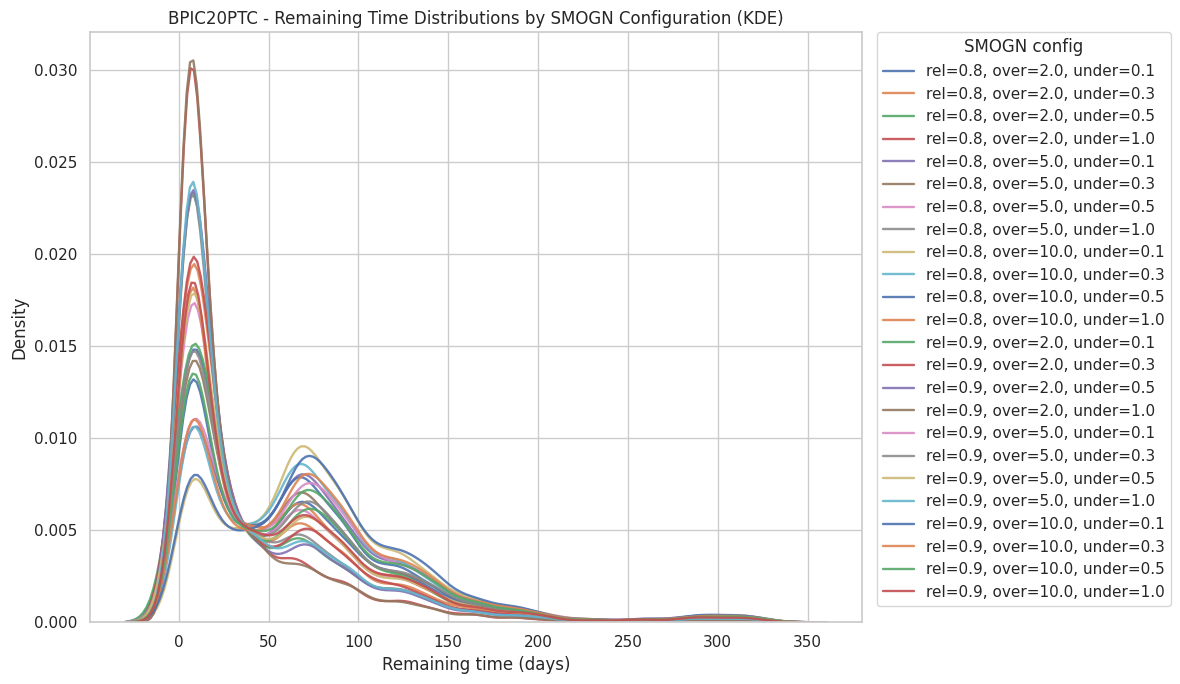

In [2]:
sns.set_theme(style='whitegrid')

# Sort labels by hyperparameter values for a stable legend ordering
ordered = summary_df[['rel_thres', 'over_ratio', 'under_ratio', 'file']].copy()
ordered = ordered.sort_values(['rel_thres', 'over_ratio', 'under_ratio'])

plt.figure(figsize=(12, 7))
for _, row in ordered.iterrows():
    rel = row['rel_thres']
    over = row['over_ratio']
    under = row['under_ratio']
    label = f'rel={rel}, over={over}, under={under}'
    vals = series_by_label[label]

    sns.kdeplot(
        vals,
        bw_adjust=1.0,
        fill=False,
        common_norm=False,
        linewidth=1.7,
        alpha=0.9,
        label=label,
    )

plt.title('BPIC20PTC - Remaining Time Distributions by SMOGN Configuration (KDE)')
plt.xlabel('Remaining time (days)')
plt.ylabel('Density')
plt.legend(title='SMOGN config', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

In [ ]:
# Optional: save the figure
out_png = Path('/ceph/lkirchdo/delay_detection/analysis/smogn_kde_distributions.png')
plt.figure(figsize=(12, 7))
for _, row in ordered.iterrows():
    label = f"rel={row['rel_thres']}, over={row['over_ratio']}, under={row['under_ratio']}"
    sns.kdeplot(series_by_label[label], bw_adjust=1.0, fill=False, common_norm=False, linewidth=1.7, alpha=0.9, label=label)

plt.title('BPIC20PTC - Remaining Time Distributions by SMOGN Configuration (KDE)')
plt.xlabel('Remaining time (days)')
plt.ylabel('Density')
plt.legend(title='SMOGN config', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()
print(f'Saved: {out_png}')

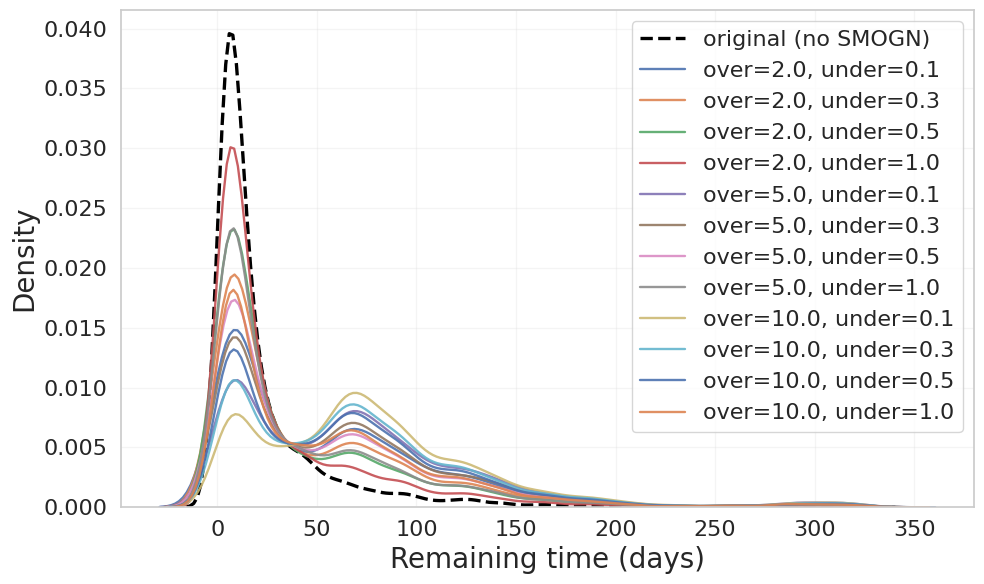

In [10]:
# KDE only for rel_thres = 0.8 + original non-SMOGN distribution
rel = 0.8
sub = summary_df[summary_df['rel_thres'] == rel].sort_values(['over_ratio', 'under_ratio'])

orig_path = Path('/ceph/lkirchdo/delay_detection/temp/DALSTM/BPIC20PTC/BPIC20PTC_train_val_true_remaining_time_values.txt')
orig_vals = np.loadtxt(orig_path, dtype=float)
orig_vals = np.atleast_1d(orig_vals)

plt.figure(figsize=(10, 6))

# Original baseline KDE (without SMOGN)
sns.kdeplot(
    orig_vals,
    bw_adjust=1.0,
    fill=False,
    common_norm=False,
    linewidth=2.4,
    alpha=1.0,
    color='black',
    linestyle='--',
    label='original (no SMOGN)',
)

for _, row in sub.iterrows():
    label = f"over={row['over_ratio']}, under={row['under_ratio']}"
    key = f"rel={row['rel_thres']}, over={row['over_ratio']}, under={row['under_ratio']}"
    sns.kdeplot(
        series_by_label[key],
        bw_adjust=1.0,
        fill=False,
        common_norm=False,
        linewidth=1.7,
        alpha=0.9,
        label=label,
    )

# plt.title('BPIC20PTC - KDE for rel_thres = 0.8 (with original baseline)')
plt.xlabel('Remaining time (days)', fontsize=20)
plt.xticks(fontsize=16)
plt.ylabel('Density', fontsize=20)
plt.yticks(fontsize=16)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right', fontsize=16)
plt.tight_layout()
# save to pdf
plt.savefig('BPIC20PTC_SMOGN.pdf', dpi=300)
plt.show()